In [9]:
import pandas as pd
df = pd.read_excel('L_SHAPE_DATA.xlsx')
df.head()

,in_WIDTH,in_LENGTH,in_HIGHT,in_ORIENTATION,in_WINDOWS_RATIO,out_FORM_FACTOR,out_S_V_RATIO,out_COOLING,out_HEATING,out_TOTAL
0,30,30,8,0,0.1,1.8905,0.4726,44.0980,1.6397,45.7377
1,40,30,8,0,0.1,1.8629,0.4657,44.0785,1.6182,45.6967
2,50,30,8,0,0.1,1.8432,0.4608,44.0635,1.6013,45.6649
3,60,30,8,0,0.1,1.8285,0.4571,44.0041,1.6009,45.6050
4,30,40,8,0,0.1,1.8629,0.4657,44.0765,1.6608,45.7373


In [10]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

df['Energy_Class'] = pd.qcut(df['out_TOTAL'], q=3, labels=['Low', 'Medium', 'High'])


X = df.drop(['out_COOLING', 'out_HEATING', 'out_TOTAL', 'Energy_Class'], axis=1)
y = df['Energy_Class']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


predictions = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='weighted')

print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")
print(f"Random Forest F1-Score: {f1 * 100:.2f}%")

Random Forest Accuracy: 82.79%
Random Forest F1-Score: 82.97%


In [11]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train_xgb)


xgb_predictions = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test_xgb, xgb_predictions)
xgb_f1 = f1_score(y_test_xgb, xgb_predictions, average='weighted')

print(f"XGBoost Accuracy: {xgb_accuracy * 100:.2f}%")
print(f"XGBoost F1-Score: {xgb_f1 * 100:.2f}%")

XGBoost Accuracy: 95.45%
XGBoost F1-Score: 95.45%


In [12]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train_aug, y_train_aug = smote.fit_resample(X_train_scaled, y_train_xgb)

print(f"Training data size before augmentation: {X_train.shape[0]} records")
print(f"Training data size after augmentation: {X_train_aug.shape[0]} records")

Training data size before augmentation: 1228 records
Training data size after augmentation: 1233 records


In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
from sklearn.metrics import accuracy_score, f1_score


ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_aug.shape[1],)),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])


ann_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Training ANN model, please wait...")
history = ann_model.fit(X_train_aug, y_train_aug,
                        epochs=50,
                        batch_size=32,
                        validation_data=(X_test_scaled, y_test_xgb),
                        verbose=0)


ann_predictions_prob = ann_model.predict(X_test_scaled)
ann_predictions = np.argmax(ann_predictions_prob, axis=1)

ann_accuracy = accuracy_score(y_test_xgb, ann_predictions)
ann_f1 = f1_score(y_test_xgb, ann_predictions, average='weighted')

print(f"ANN Accuracy: {ann_accuracy * 100:.2f}%")
print(f"ANN F1-Score: {ann_f1 * 100:.2f}%")

Training ANN model, please wait...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
ANN Accuracy: 86.04%
ANN F1-Score: 86.26%


In [14]:
from tensorflow.keras.layers import SimpleRNN, Dense, Input

X_train_rnn = X_train_aug.reshape((X_train_aug.shape[0], 1, X_train_aug.shape[1]))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

rnn_model = Sequential([
    Input(shape=(1, X_train_aug.shape[1])),
    SimpleRNN(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])


rnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


print("Training RNN model, please wait...")
history_rnn = rnn_model.fit(X_train_rnn, y_train_aug,
                            epochs=50,
                            batch_size=32,
                            validation_data=(X_test_rnn, y_test_xgb),
                            verbose=0)

rnn_predictions_prob = rnn_model.predict(X_test_rnn)
rnn_predictions = np.argmax(rnn_predictions_prob, axis=1)

rnn_accuracy = accuracy_score(y_test_xgb, rnn_predictions)
rnn_f1 = f1_score(y_test_xgb, rnn_predictions, average='weighted')

print(f"RNN Accuracy: {rnn_accuracy * 100:.2f}%")
print(f"RNN F1-Score: {rnn_f1 * 100:.2f}%")

Training RNN model, please wait...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
RNN Accuracy: 87.01%
RNN F1-Score: 87.18%


In [15]:
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Input


X_train_cnn = X_train_rnn
X_test_cnn = X_test_rnn


cnn_model = Sequential([
    Input(shape=(1, X_train_aug.shape[1])),
    Conv1D(filters=32, kernel_size=1, activation='relu'),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])


cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

print("Training CNN model, please wait...")
history_cnn = cnn_model.fit(X_train_cnn, y_train_aug,
                            epochs=50,
                            batch_size=32,
                            validation_data=(X_test_cnn, y_test_xgb),
                            verbose=0)


cnn_predictions_prob = cnn_model.predict(X_test_cnn)
cnn_predictions = np.argmax(cnn_predictions_prob, axis=1)

cnn_accuracy = accuracy_score(y_test_xgb, cnn_predictions)
cnn_f1 = f1_score(y_test_xgb, cnn_predictions, average='weighted')

print(f"CNN Accuracy: {cnn_accuracy * 100:.2f}%")
print(f"CNN F1-Score: {cnn_f1 * 100:.2f}%")

Training CNN model, please wait...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
CNN Accuracy: 87.01%
CNN F1-Score: 87.15%


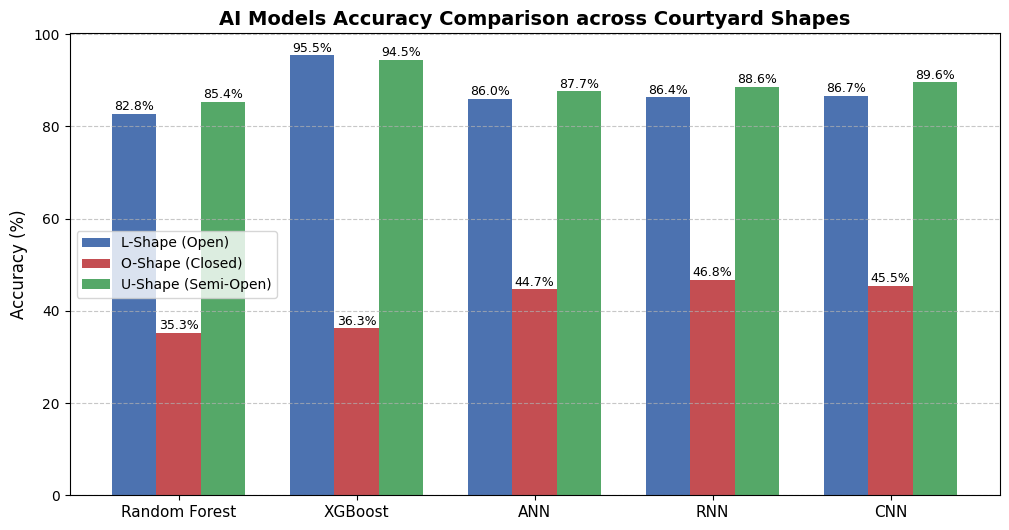

In [16]:
import matplotlib.pyplot as plt
import numpy as np


models = ['Random Forest', 'XGBoost', 'ANN', 'RNN', 'CNN']
L_scores = [82.79, 95.45, 86.04, 86.36, 86.69]
O_scores = [35.29, 36.27, 44.74, 46.79, 45.45]
U_scores = [85.39, 94.48, 87.66, 88.64, 89.61]

x = np.arange(len(models))
width = 0.25


fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, L_scores, width, label='L-Shape (Open)', color='#4C72B0')
rects2 = ax.bar(x, O_scores, width, label='O-Shape (Closed)', color='#C44E52')
rects3 = ax.bar(x + width, U_scores, width, label='U-Shape (Semi-Open)', color='#55A868')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('AI Models Accuracy Comparison across Courtyard Shapes', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.show()